In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Loading the data

In [3]:
df = pd.read_csv("../data/imputed_unfiltered_data.csv")
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.set_index('Timestamp', drop=True)
df.sort_index(inplace=True)
df = df.asfreq('h')
df.shape

(5832, 15)

## Choosing exogenous predictors

Same predictors as the ARX/ARMAX notebooks: irradiation, ambient temperature, wind, humidity and air quality.

In [4]:
exog_cols = [
       'Solar_Radiation_Wm2', 'Outdoor_Temp_C',
       'Wind_Speed_ms', 'Humidity_pct', 'AQI_US'
]

df[['DC'] + exog_cols].corr()['DC']

DC                     1.000000
Solar_Radiation_Wm2    0.913771
Outdoor_Temp_C         0.348489
Wind_Speed_ms          0.306683
Humidity_pct          -0.605835
AQI_US                -0.144575
Name: DC, dtype: float64

# Splitting the data

Train: (4082, 15), Test: (1166, 15), Validation: (584, 15)


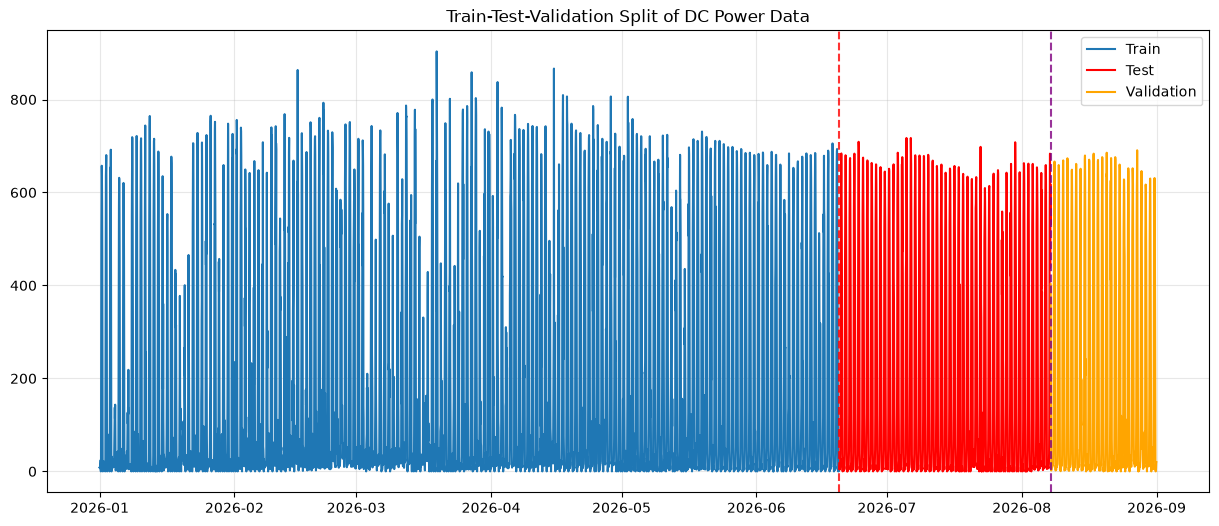

In [5]:
train_percent = 0.7
test_percent = 0.2

n_total = len(df)
train_end_index = int(n_total * train_percent)
test_end_index = int(n_total * (train_percent + test_percent))

train_df = df.iloc[:train_end_index]
test_df = df.iloc[train_end_index:test_end_index]
validation_df = df.iloc[test_end_index:]

split_time_1 = train_df.index.max()
split_time_2 = test_df.index.max()

print(f"Train: {train_df.shape}, Test: {test_df.shape}, Validation: {validation_df.shape}")

plt.figure(figsize=(15, 6))
plt.plot(train_df.index, train_df['DC'], label='Train')
plt.plot(test_df.index, test_df['DC'], label='Test', color='red')
plt.plot(validation_df.index, validation_df['DC'], label='Validation', color='orange')
plt.axvline(split_time_1, color='red', linestyle='--', alpha=0.8)
plt.axvline(split_time_2, color='purple', linestyle='--', alpha=0.8)
plt.title('Train-Test-Validation Split of DC Power Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Keeping the DatetimeIndex

Unlike the filtered notebooks, the unfiltered data is a continuous hourly series, so `statsmodels` can use the real `DatetimeIndex` (freq='h') directly instead of a `RangeIndex`.

In [6]:
train_series = train_df['DC']
train_exog = train_df[exog_cols]

test_series = test_df['DC']
test_exog = test_df[exog_cols]

# Checking stationarity (confirming d)

An Augmented Dickey-Fuller test on the training series tells us whether we need non-seasonal differencing (`d`).

In [7]:
def adf_report(series, label):
    result = adfuller(series.dropna())
    print(f"{label}: ADF stat={result[0]:.3f}, p-value={result[1]:.4f}")
    return result[1]

p_value = adf_report(train_series, "Level (d=0)")

d = 0
if p_value <= 0.05:
    print(f"\nSeries is stationary at the level (p-value={p_value:.4f} <= 0.05).")
else:
    print(f"\nWarning: p-value={p_value:.4f} > 0.05 - series may not be stationary at the level.")
print(f"d = {d}")

Level (d=0): ADF stat=-8.610, p-value=0.0000

Series is stationary at the level (p-value=0.0000 <= 0.05).
d = 0


## Seasonal period

The data is hourly with a clear daily cycle (sunrise-to-sunset), so we use `s = 24`. Solar radiation is already in the exog set and carries most of that cycle, so we keep the seasonal difference `D = 0` and let small seasonal AR/MA terms pick up whatever remains.

In [8]:
s = 24
D = 0

# Choosing (p, q, P, Q) via grid search on AIC

With `d` and `D` fixed, we grid-search a small range of non-seasonal and seasonal orders and keep the combination with the lowest AIC. This can take a few minutes.

In [9]:
p_range = range(0, 4)
q_range = range(0, 4)
P_range = range(0, 2)
Q_range = range(0, 2)

results = []
for p in p_range:
    for q in q_range:
        if p == 0 and q == 0:
            continue
        for P in P_range:
            for Q in Q_range:
                try:
                    m = SARIMAX(
                        train_series, exog=train_exog,
                        order=(p, d, q),
                        seasonal_order=(P, D, Q, s),
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False)
                    results.append((p, q, P, Q, m.aic))
                except Exception:
                    results.append((p, q, P, Q, None))

results_df = pd.DataFrame(results, columns=['p', 'q', 'P', 'Q', 'aic']).dropna().sort_values('aic')
results_df.head(10)

,p,q,P,Q,aic
51,3,1,1,1,44891.809719
47,3,0,1,1,44891.837252
19,1,1,1,1,44926.063022
11,0,3,1,1,44960.783351
35,2,1,1,1,45001.373310
15,1,0,1,1,45030.626091
27,1,3,1,1,45045.145328
7,0,2,1,1,45049.749245
59,3,3,1,1,45058.774984
43,2,3,1,1,45069.409768


In [10]:
best_p, best_q, best_P, best_Q, best_aic = results_df.iloc[0][['p', 'q', 'P', 'Q', 'aic']]
best_p, best_q, best_P, best_Q = int(best_p), int(best_q), int(best_P), int(best_Q)
print(f"Best order: SARIMAX({best_p},{d},{best_q})x({best_P},{D},{best_Q},{s}), AIC={best_aic:.2f}")

final_model = SARIMAX(
    train_series, exog=train_exog,
    order=(best_p, d, best_q),
    seasonal_order=(best_P, D, best_Q, s),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(final_model.summary())

Best order: SARIMAX(3,0,1)x(1,0,1,24), AIC=44891.81
                                     SARIMAX Results                                      
Dep. Variable:                                 DC   No. Observations:                 4082
Model:             SARIMAX(3, 0, 1)x(1, 0, 1, 24)   Log Likelihood              -22433.905
Date:                            Thu, 24 Sep 2026   AIC                          44891.810
Time:                                    15:59:50   BIC                          44967.502
Sample:                                01-01-2026   HQIC                         44918.622
                                     - 06-20-2026                                         
Covariance Type:                              opg                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Solar_Radiation_Wm2     0.9413      0.011   

# Test-set forecast

Forecasting requires future exogenous values (`exog=test_exog`) — in production these would come from a weather forecast; here we use the known test-set values to evaluate the model itself.

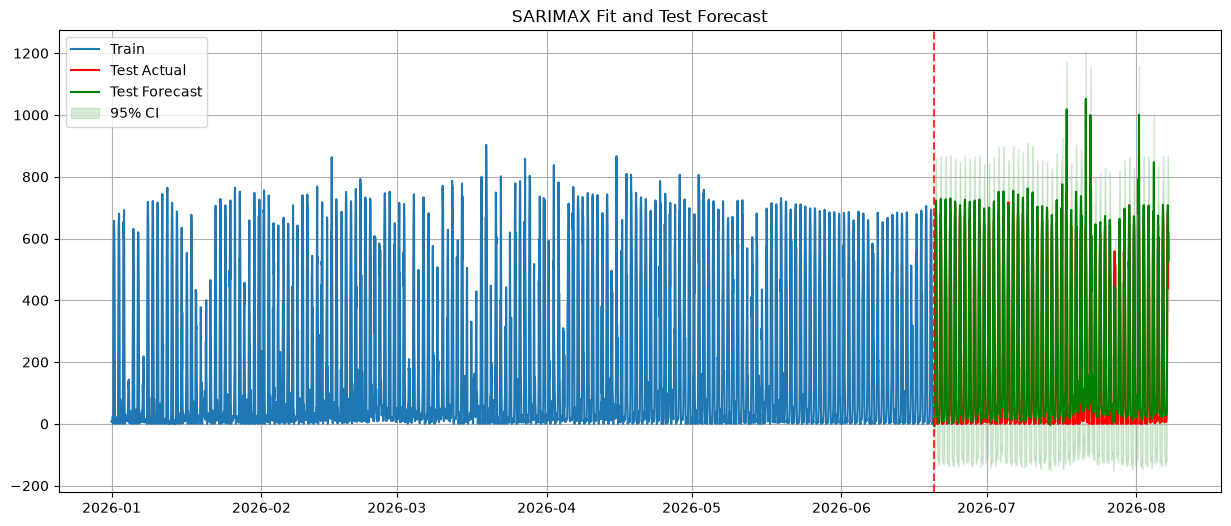

In [11]:
forecast_res = final_model.get_forecast(steps=len(test_series), exog=test_exog)
pred_test = forecast_res.predicted_mean

conf_int = forecast_res.conf_int()

plt.figure(figsize=(15, 6))
plt.plot(train_df.index, train_df['DC'], label='Train')
plt.plot(test_df.index, test_df['DC'], label='Test Actual', color='red')
plt.plot(pred_test.index, pred_test, label='Test Forecast', color='green')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                  color='green', alpha=0.15, label='95% CI')
plt.axvline(split_time_1, color='red', linestyle='--', alpha=0.8)
plt.title('SARIMAX Fit and Test Forecast')
plt.legend()
plt.grid(True)
plt.show()

## Model diagnostics

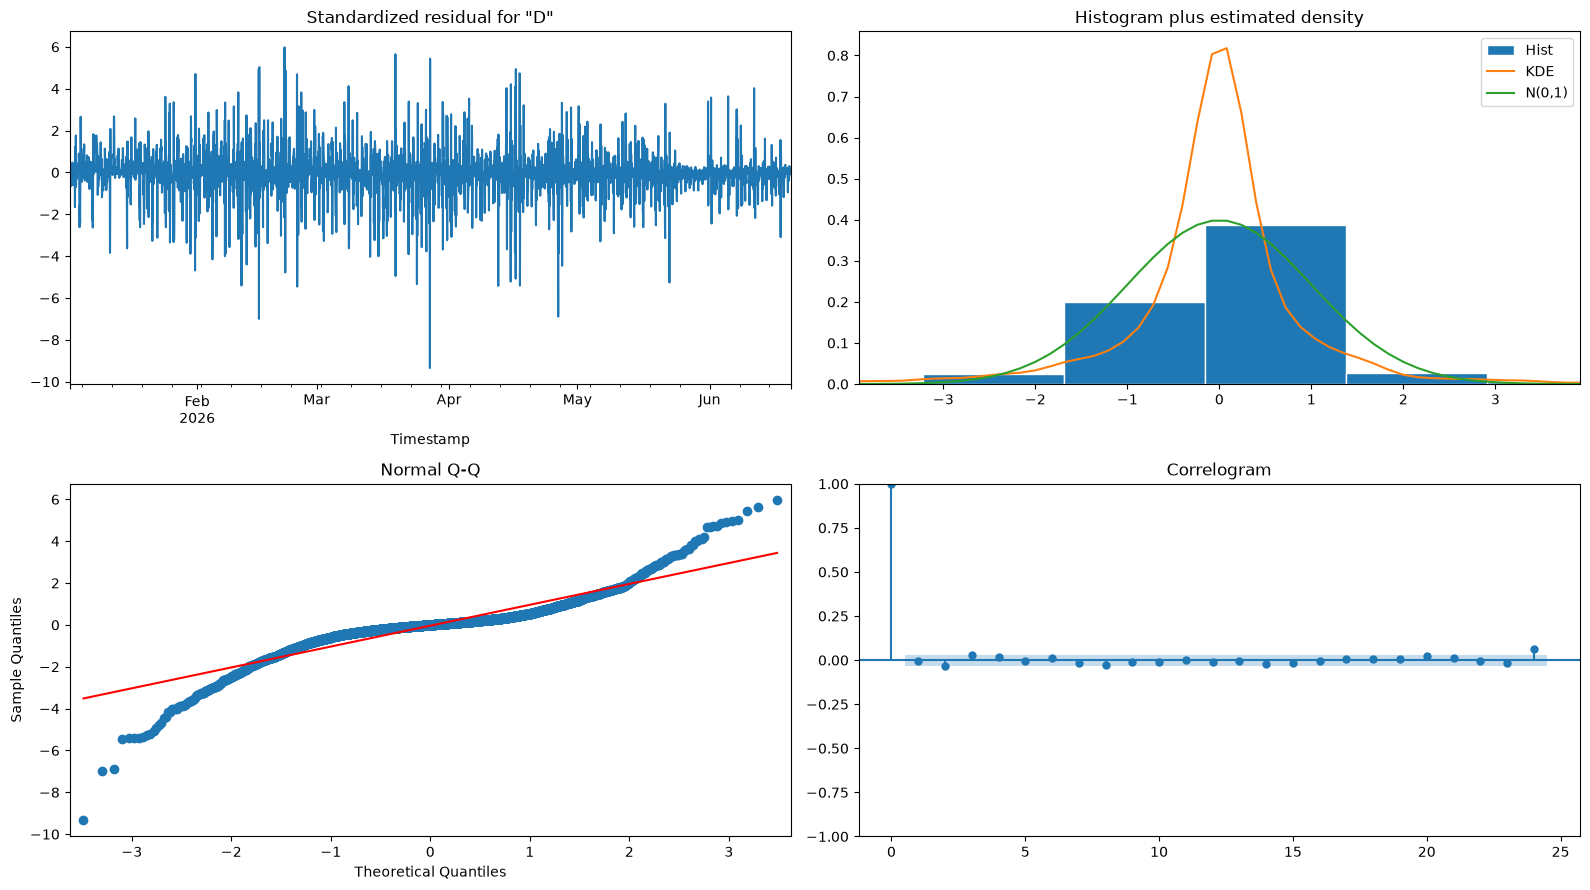

In [12]:
fig = plt.figure(figsize=(16, 9))
fig = final_model.plot_diagnostics(fig=fig, lags=24)
plt.tight_layout()
plt.show()

## Rolling one-step-ahead forecast on the test set

In [13]:
dc_full = pd.concat([train_df['DC'], test_df['DC']])
exog_full = pd.concat([train_df[exog_cols], test_df[exog_cols]])

ar_predictions = []
n_train = len(train_df)

for i in range(n_train, n_train + len(test_df)):
    updated_res = final_model.apply(dc_full[:i], exog=exog_full[:i])
    next_exog = exog_full.iloc[[i]]
    step_forecast = updated_res.get_forecast(steps=1, exog=next_exog)
    ar_predictions.append(step_forecast.predicted_mean.iloc[0])

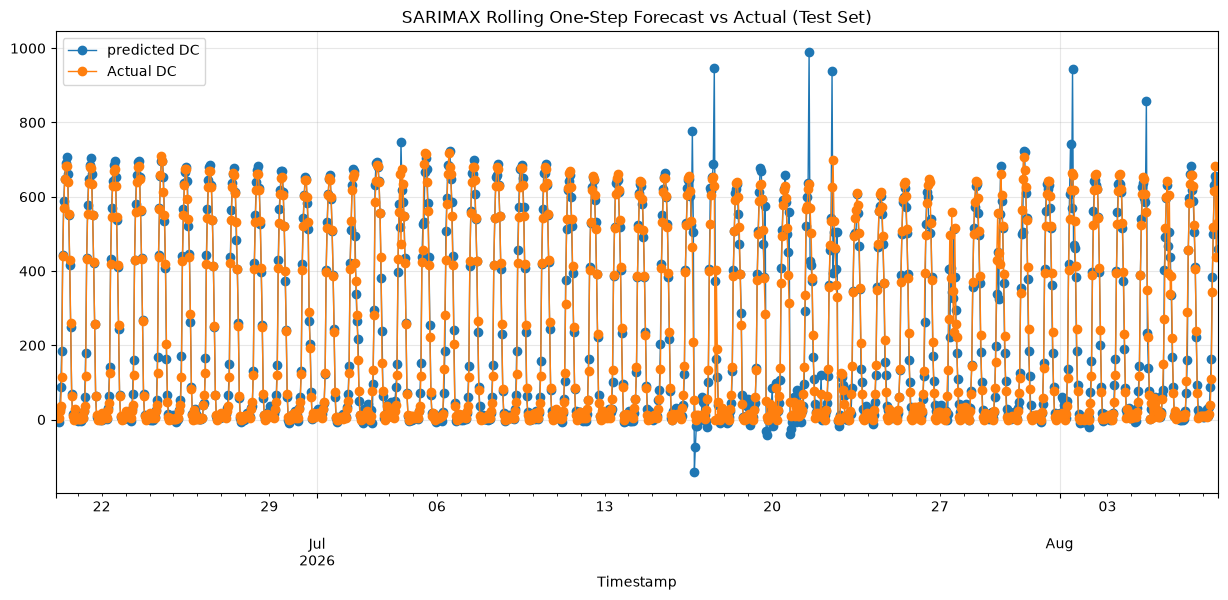

In [14]:
predictions = pd.DataFrame({
    "predicted DC": ar_predictions,
    "Actual DC": test_df['DC'].values,
}, index=test_df.index)

_, ax = plt.subplots(figsize=(15, 6))
predictions.plot(ax=ax, marker='o', linestyle='-', linewidth=1)
plt.title('SARIMAX Rolling One-Step Forecast vs Actual (Test Set)')
plt.grid(True, alpha=0.3)
plt.show()

## Evaluation metrics

In [15]:
mse = mean_squared_error(predictions['Actual DC'], predictions['predicted DC'])
print('Test MSE: %.5f' % mse)

mape = np.mean(np.abs((predictions['Actual DC'] - predictions['predicted DC']) / (predictions['Actual DC'] + 1)))
print('Test MAPE-like: %.3f' % mape)

mae = mean_absolute_error(predictions['Actual DC'], predictions['predicted DC'])
print('Test MAE: %.3f' % mae)

r2 = r2_score(predictions['Actual DC'], predictions['predicted DC'])
print(f'R²: {r2:.3f}')

Test MSE: 2062.26108
Test MAPE-like: 1.266
Test MAE: 21.531
R²: 0.967


## Validation set forecast

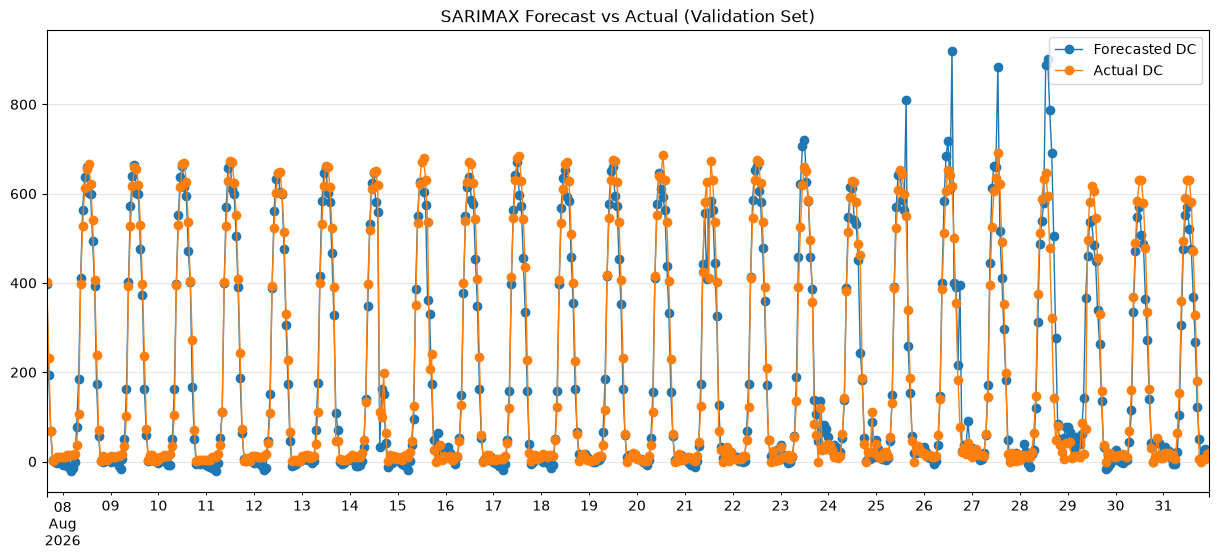

In [16]:
validation_exog = validation_df[exog_cols]

val_forecast_res = final_model.apply(dc_full, exog=exog_full).get_forecast(
    steps=len(validation_df), exog=validation_exog
)
forecast_values = val_forecast_res.predicted_mean

predictions_val = pd.DataFrame({
    "Forecasted DC": forecast_values,
    "Actual DC": validation_df['DC'],
})

_, ax = plt.subplots(figsize=(15, 6))
predictions_val.plot(ax=ax, marker='o', linestyle='-', linewidth=1)
plt.title('SARIMAX Forecast vs Actual (Validation Set)')
plt.grid(True, alpha=0.3)
plt.show()

### Save the SARIMAX model and its metrics

In [17]:
import os

os.makedirs("../models", exist_ok=True)
final_model.save("../models/sarimax_model_unfiltered.pkl")
print("Saved SARIMAX model to ../models/sarimax_model_unfiltered.pkl")

os.makedirs("../results", exist_ok=True)
metrics_path = "../results/model_metrics.csv"

row = {
    "Model": "SARIMAX",
    "Data": "unfiltered",
    "Order": f"({best_p},{d},{best_q})x({best_P},{D},{best_Q},{s})",
    "AIC": final_model.aic,
    "BIC": final_model.bic,
    "Test MSE": mse,
    "Test MAE": mae,
    "Test MAPE-like": mape,
    "Test R2": r2,
}

if os.path.exists(metrics_path):
    metrics_df = pd.read_csv(metrics_path)
    metrics_df = metrics_df[~((metrics_df["Model"] == row["Model"]) & (metrics_df["Data"] == row["Data"]))]
    metrics_df = pd.concat([metrics_df, pd.DataFrame([row])], ignore_index=True)
else:
    metrics_df = pd.DataFrame([row])

metrics_df.to_csv(metrics_path, index=False)
print(f"Saved metrics to {metrics_path}")

Saved SARIMAX model to ../models/sarimax_model_unfiltered.pkl
Saved metrics to ../results/model_metrics.csv
